# Modeling (Jordan Blackman)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

The winning model I want to focus on is XGBoost

# Data Type Transformation and Removing Overfitting Features

In [1]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# # log price, protein, and sugars to handle significant skew
# df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
# df['log_protein_g'] = np.log1p(df['protein_g'])
# df['log_sugars_g'] = np.log1p(df['sugars_g'])

# # square root serving size, calories, fat, carbs, sodium to handle small skew
# df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
# df['sqrt_calories'] = np.sqrt(df['calories'])
# df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
# df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
# df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# # flip average rating to handle left skew, units are flipped
# # reflect constant is the max rating (5) + 1 so data leakage is not introduced with new data
# reflect_constant = 5 + 1
# df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
# df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
#                       'serving_size_g', 'calories', 'total_fat_g',
#                       'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are not being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
price_usd_normalized,8.66,2.78,5.77,8.47,2.79
serving_size_g,224.9,151.7,294.1,87.7,125.4


# Test Train Split

In [2]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [3]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

# find categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

# find categorical indices
cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

# show data before SMOTE
print("Before SMOTE")
print(Y_train.value_counts())

# conduct SMOTE, using random state, only on the training data
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

# show data after SMOTE to check balance.
print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [4]:
# # encode variables
# X_train_encoded = pd.get_dummies(X_train, drop_first=True)
# X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# # align encoded variables
# X_test_encoded = X_test_encoded.reindex(
#     columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [5]:
# from sklearn.preprocessing import StandardScaler

# # scale variables
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_encoded)
# X_test_scaled = scaler.transform(X_test_encoded)

# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

# Establish Evaluation Function

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    # set up calculations
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    # print calculations
    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        # plot confusion matrix
        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    # save variables per model
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [7]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):
    # fit
    model.fit(x_train, y_train)
    # predict using test
    y_pred = model.predict(x_test)

    # get y predictions data
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    # run previously established function to evaluate model performance
    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    # return the metrics
    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



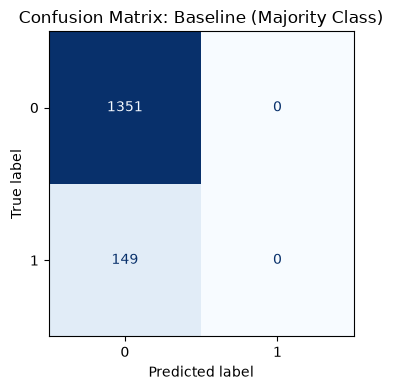

In [8]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- XGBoost Evaluation ---
Accuracy:    0.9527
Precision:   0.7143
Recall:      0.8725 (Sensitivity)
Specificity: 0.9615
F1-Score:    0.7855
ROC AUC:     0.9829
------------------------------



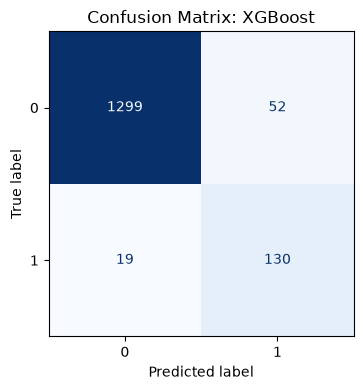

In [9]:
# XGBoost
from xgboost import XGBClassifier

# convert categorical columns to category
cat_cols = ['item_category', 'item_subcategory', 'country', 'city_tier']
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# start with reasonable settings, tune later
xgb_model = XGBClassifier(
    n_estimators=100,  # number of trees to build
    learning_rate=0.1,  # how quickly the model adapts to training data
    max_depth=5,  # max depth of trees
    eval_metric='logloss',  # metric to optimize with
    enable_categorical=True,  # handle categoricals without one hot encoding
    random_state=42  # set for reproduceability
)

# evaluate XGBoost Model
xgb_metrics = train_and_evaluate(
    xgb_model,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="XGBoost"
)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'colsample_bytree': np.float64(0.8244973703390804), 'learning_rate': np.float64(0.12487806242613694), 'max_depth': 5, 'n_estimators': 255, 'subsample': np.float64(0.9395655297064336)}
--- Tuned XGBoost Evaluation ---
Accuracy:    0.9680
Precision:   0.8344
Recall:      0.8456 (Sensitivity)
Specificity: 0.9815
F1-Score:    0.8400
ROC AUC:     0.9834
------------------------------



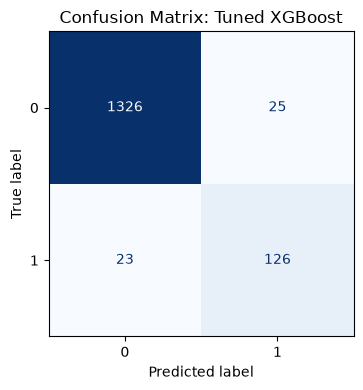

In [11]:
# XGBoost with tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# set up model
xgb_model = XGBClassifier(
    random_state=42,  # set for reproduceability
    eval_metric='logloss',  # metric to optimize with
    enable_categorical=True,  # handle categoricals without one hot encoding
    early_stopping_rounds=20  # add in early stopping to not overfit
)

# set up parameters
param_dist = {
    # how quickly the model adapts to training data
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 7),  # max depth of trees
    'n_estimators': randint(50, 300),  # number of trees to build
    # fraction of training data sampled to grow a tree
    'subsample': uniform(0.6, 0.4),
    # fraction of features randomly chosen for each tree
    'colsample_bytree': uniform(0.6, 0.4)
}

# search for best parameters
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,  # number of times to run the parameter combinations
    scoring='roc_auc',  # scoring based on ROC AUC
    cv=3,  # 3 fold cross validated
    verbose=1,  # print what is being fit
    random_state=42  # set for reproduceability
)

# fit the random search
random_search.fit(X_train, Y_train,
                  eval_set=[(X_test, Y_test)],
                  verbose=False)

# print best parameters
print(f"Best Parameters: {random_search.best_params_}")

# train and evaluate tuned XGBoost model
best_xgb = random_search.best_estimator_

# turn off early stopping rounds
best_xgb.set_params(early_stopping_rounds=None)

tuned_xgb_metrics = train_and_evaluate(
    best_xgb,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Tuned XGBoost"
)

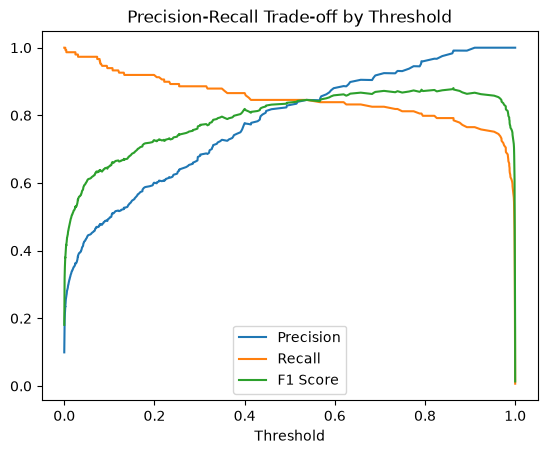

In [12]:
# show precision recall tradeoff with f1 score
from sklearn.metrics import precision_recall_curve

# get predicted probabilities on the test set
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# compute precision, recall, and thresholds across the curve
precisions, recalls, thresholds = precision_recall_curve(Y_test, y_prob_tuned)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# plot precision, recall, and f1 scores by threshold
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Trade-off by Threshold")
plt.show()

# Compare Models

In [13]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# Convert to DataFrame
results_df = pd.DataFrame(model_results)

# Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# Display the table
results_df.sort_values(by='f1_score', ascending=False). round(3)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Tuned XGBoost,0.968,0.834,0.846,0.981,0.840,0.983
XGBoost,0.953,0.714,0.872,0.962,0.785,0.983
Baseline (Majority Class),0.901,0.000,0.000,1.000,0.000,0.500


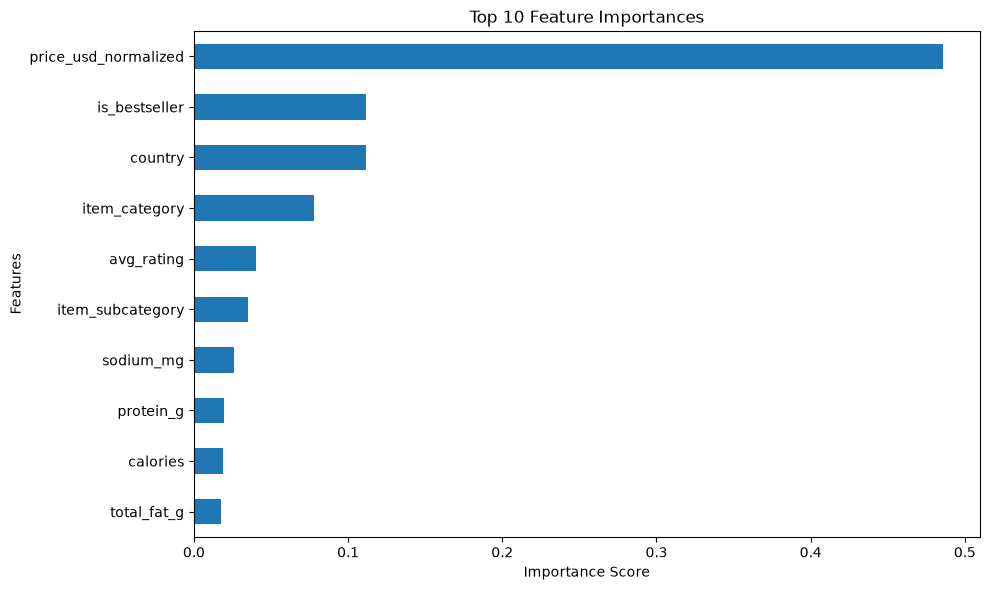

In [14]:
# Get feature importance
importances = best_xgb.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(
    importances, index=feature_names).sort_values(ascending=False)

# plot top 10 feature importance
plt.figure(figsize=(10, 6))
feat_imp.head(10).sort_values(ascending=True).plot(
    kind='barh', title="Top 10 Feature Importances", )
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [15]:
print(dict(enumerate(X_train['item_category'].cat.categories)))
print(dict(enumerate(X_train['item_subcategory'].cat.categories)))
print(dict(enumerate(X_train['country'].cat.categories)))
print(dict(enumerate(X_train['city_tier'].cat.categories)))

{0: 'Burger', 1: 'Dessert', 2: 'Drink', 3: 'Pizza', 4: 'Rice/Bowl', 5: 'Salad', 6: 'Sandwich', 7: 'Sides'}
{0: 'Non-Veg', 1: 'Veg', 2: 'Vegan'}
{0: 'Australia', 1: 'Canada', 2: 'India', 3: 'UK', 4: 'USA'}
{0: 'metro', 1: 'tier-2', 2: 'tier-3'}


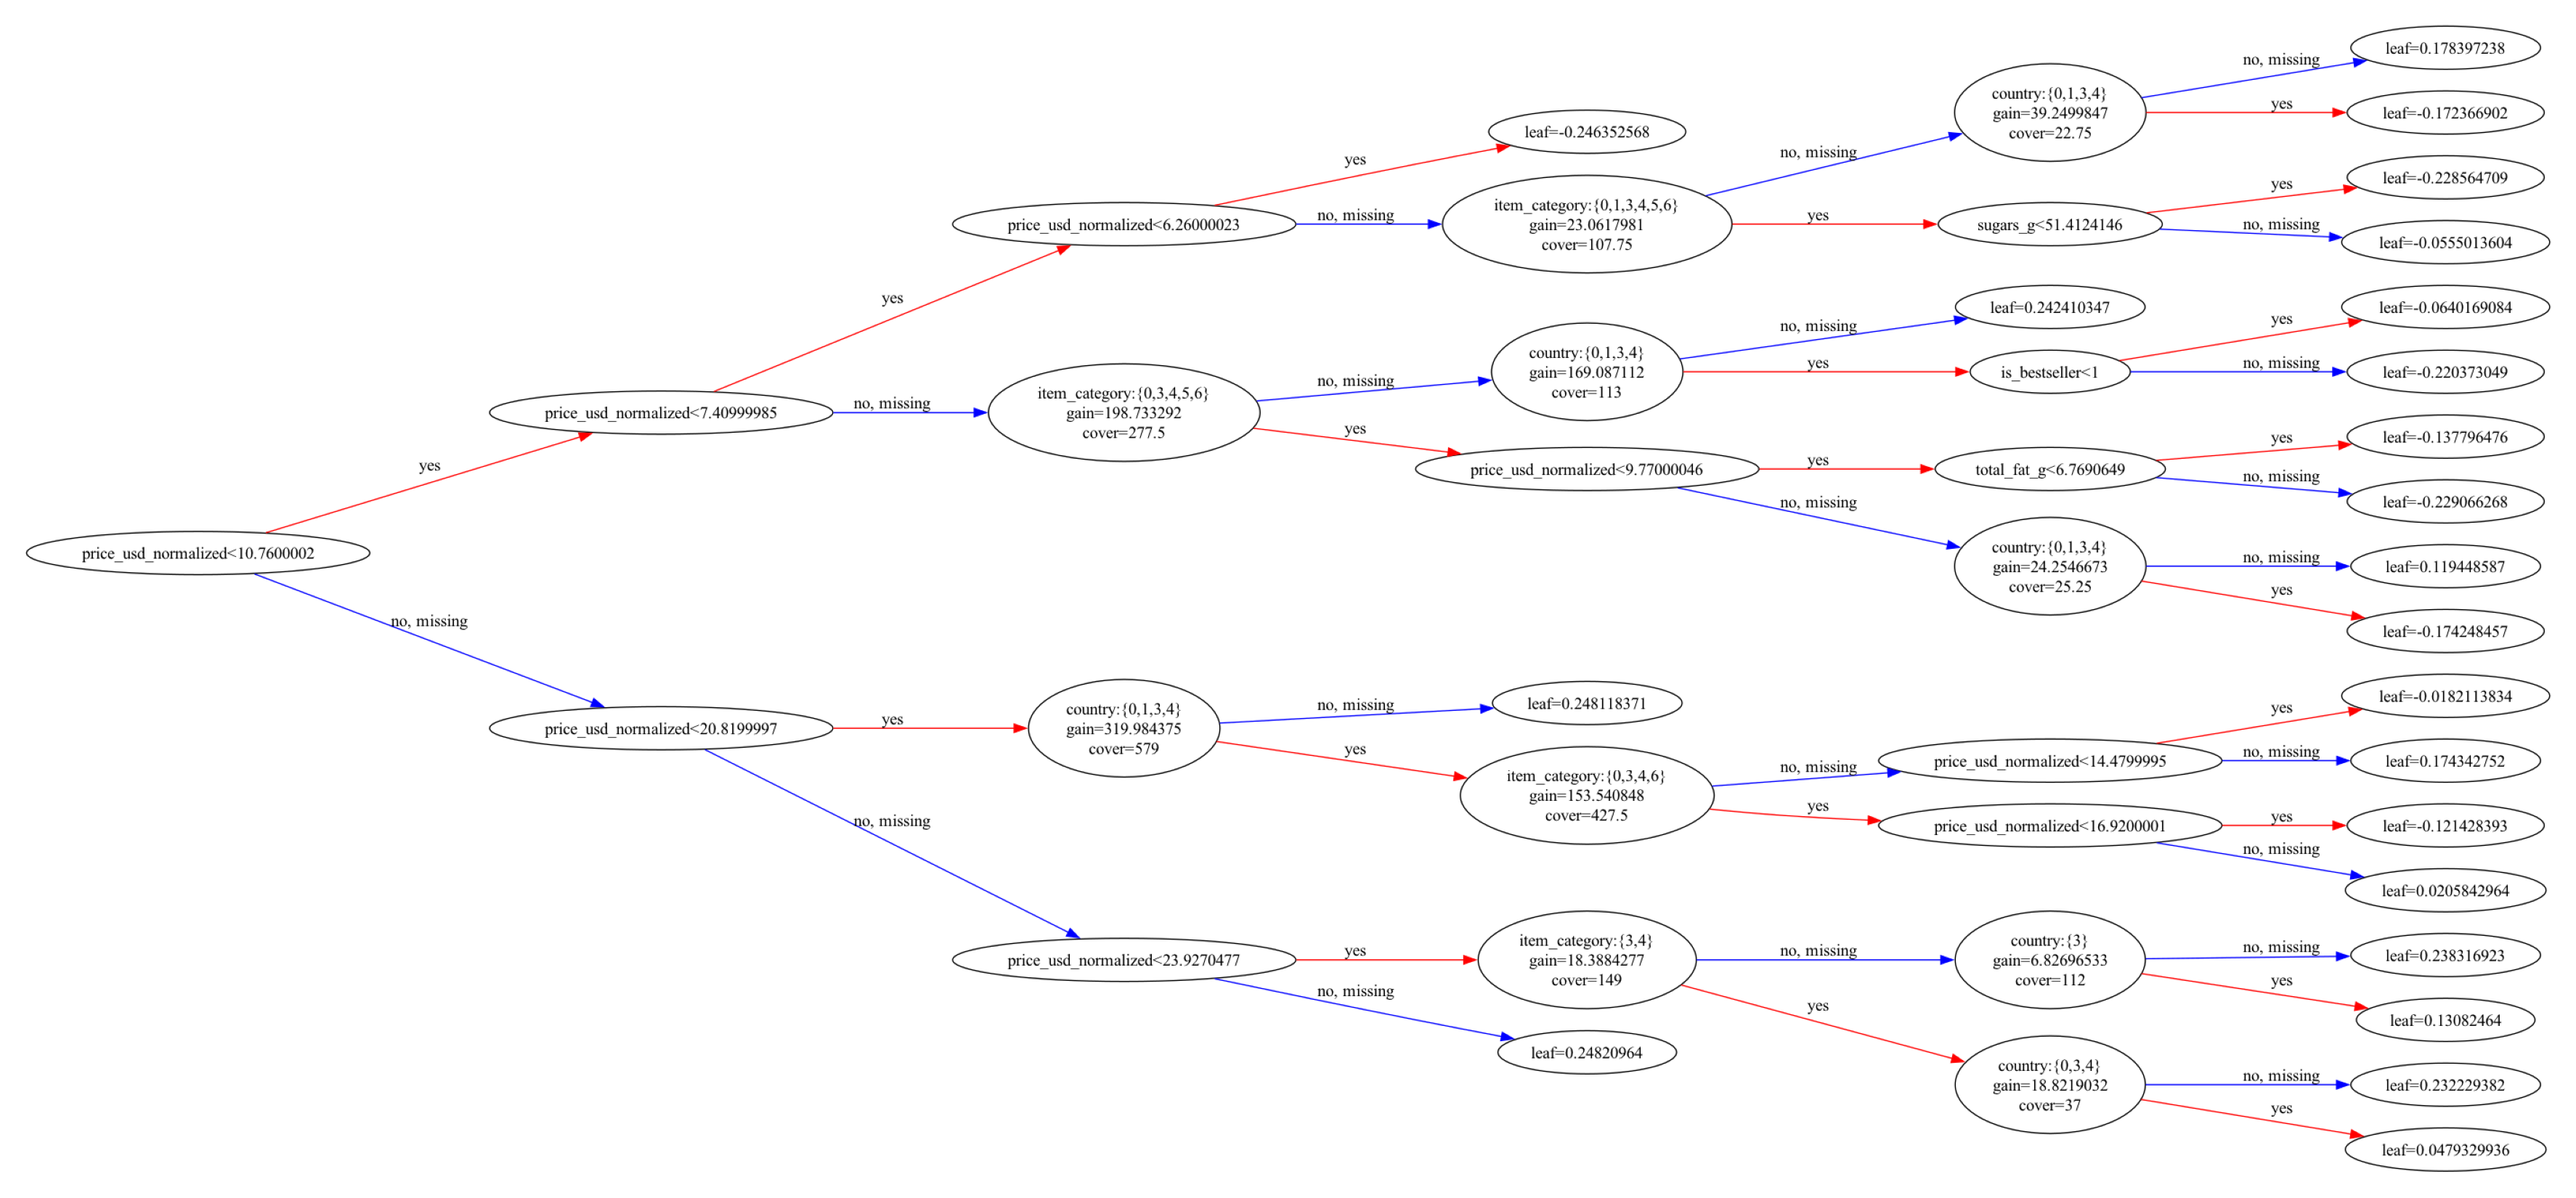

In [16]:
from xgboost import plot_tree

# increase DPI and figure size
fig, ax = plt.subplots(figsize=(15, 10), dpi=300)

# plot tree
plot_tree(best_xgb, tree_idx=0, ax=ax, rankdir='LR')

# save and show tree
plt.savefig("xgboost_tree_high_res.pdf", format="pdf", bbox_inches="tight")

plt.show()

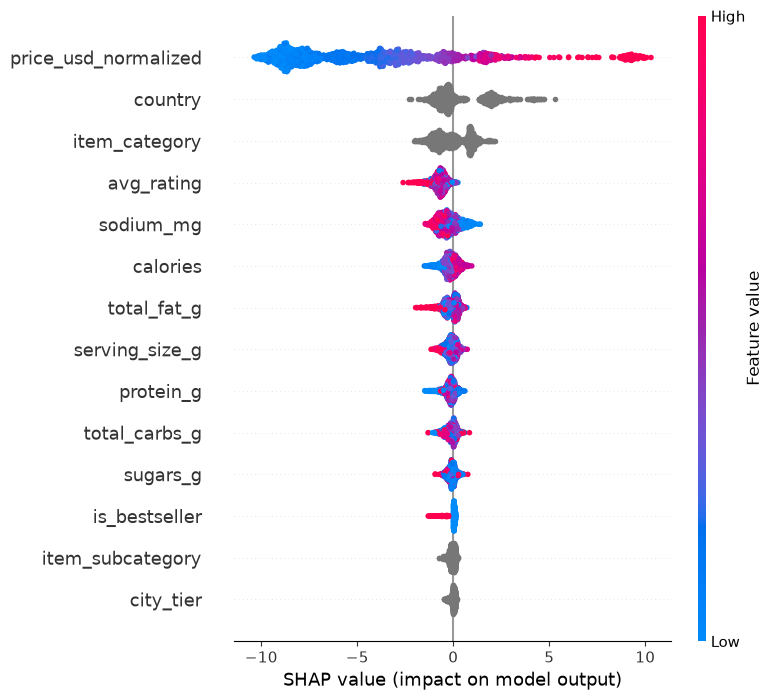

In [17]:
import shap

# set up javascript visualizations
shap.initjs()

# create a tree explainer for the XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# generate the summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

# Other Tested Models

In [ ]:
# # Naive Bayes
# from sklearn.naive_bayes import GaussianNB

# nb_1 = GaussianNB()

# nb_1_metrics = train_and_evaluate(
#     nb_1,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Naive Bayes 1"
# )

In [ ]:
# # Decision Tree (CART)

# from sklearn.tree import DecisionTreeClassifier

# cart_1 = DecisionTreeClassifier(random_state=42, class_weight=None)

# cart_1_metrics = train_and_evaluate(
#     cart_1,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Cart 1"
# )

In [ ]:
# # Decision Tree (C5.0)

# cart_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# c5_metrics = train_and_evaluate(
#     cart_entropy,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="C5.0 1"
# )

In [ ]:
# # kNN Classifier (selected)
# from sklearn.neighbors import KNeighborsClassifier

# knn_1 = KNeighborsClassifier(n_neighbors=4)

# knn_metrics = train_and_evaluate(
#     knn_1,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="KNN (n=4)"
# )

In [ ]:
# # Logistic Regression

# from sklearn.linear_model import LogisticRegression

# log_reg_1 = LogisticRegression(random_state=42, max_iter=1000)

# log_reg_1_metrics = train_and_evaluate(
#     log_reg_1,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Logistic Regression"

# )

In [ ]:
# # SVC (Linear)

# from sklearn.svm import SVC
# from sklearn.calibration import CalibratedClassifierCV

# base_svc_linear = SVC(kernel='linear', random_state=42)
# svc_linear = CalibratedClassifierCV(base_svc_linear, ensemble=False)

# svc_linear_metrics = train_and_evaluate(
#     svc_linear,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="SVC Linear"
# )

In [ ]:
# # SVC (RBF)
# base_svc_rbf = SVC(kernel='rbf', random_state=42)
# svc_rbf = CalibratedClassifierCV(base_svc_rbf, ensemble=False)

# svc_rbf_metrics = train_and_evaluate(
#     svc_rbf,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="SVC RBF"
# )

In [ ]:
# # SVC (Polynomial)
# base_svc_poly = SVC(kernel='poly', random_state=42)
# svc_poly = CalibratedClassifierCV(base_svc_poly, ensemble=False)

# svc_poly_metrics = train_and_evaluate(
#     svc_poly,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="SVC Polynomial"
# )

In [ ]:
# # SVC (Sigmoid)
# base_svc_sigmoid = SVC(kernel='sigmoid', random_state=42)
# svc_sigmoid = CalibratedClassifierCV(base_svc_sigmoid, ensemble=False)

# svc_sigmoid_metrics = train_and_evaluate(
#     svc_sigmoid,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="SVC Sigmoid"
# )

In [ ]:
# # Random Forest Classifier
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# rf_metrics = train_and_evaluate(
#     rf_model,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Random Forest"
# )

In [ ]:
# # AdaBoost with Random Forest Base

# from sklearn.ensemble import AdaBoostClassifier

# ada_model = AdaBoostClassifier(
#     estimator=DecisionTreeClassifier(max_depth=1),
#     n_estimators=200,
#     learning_rate=0.05,
#     random_state=42
# )

# ada_metrics = train_and_evaluate(
#     ada_model,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="AdaBoost"
# )

In [ ]:
# # Neural Network

# from sklearn.neural_network import MLPClassifier

# mlp_model = MLPClassifier(
#     hidden_layer_sizes=(64, 32),
#     activation='relu',
#     solver='adam',
#     alpha=0.05,
#     max_iter=1000,
#     learning_rate_init=0.001,
#     early_stopping=True,
#     random_state=42
# )

# mlp_metrics = train_and_evaluate(
#     mlp_model,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Neural Network (Regularized)"
# )

# Explore Hyperparameters and Cost Matrices

In [ ]:
# # kNN Classifier tuning k

# all_results = []

# for k in range(1, 101):
#     knn = KNeighborsClassifier(n_neighbors=k)

#     metrics = train_and_evaluate(
#         knn, X_train_scaled, Y_train, X_test_scaled, Y_test,
#         model_name=f"k={k}", verbose=False
#     )
#     all_results.append(metrics)

# df = pd.DataFrame(all_results)

# df['k'] = df['model'].str.extract('(\d+)').astype(int)

# metrics_to_check = ['accuracy', 'precision',
#                     'recall', 'specificity',
#                     'f1_score', 'roc_auc']

# for metric in metrics_to_check:
#     print(f"--- Top 2 k-values for {metric.upper()} ---")

#     top_2 = df.nlargest(2, metric)

#     for i, row in top_2.iterrows():
#         print(f"Rank {i+1}: k = {row['k']} | Score = {row[metric]:.4f}")
#     print("\n")

In [ ]:
# from scipy.stats import uniform

# mlp_model = MLPClassifier(max_iter=500, random_state=42)

# param_dist_mlp = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
#     'activation': ['tanh', 'relu'],
#     'alpha': uniform(0.0001, 0.05),
#     'learning_rate_init': uniform(0.001, 0.05)
# }

# random_search_mlp = RandomizedSearchCV(
#     estimator=mlp_model,
#     param_distributions=param_dist_mlp,
#     n_iter=20,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     random_state=42
# )

# random_search_mlp.fit(X_train_scaled, Y_train)
# print(f"Best Parameters: {random_search_mlp.best_params_}")

# best_mlp = random_search_mlp.best_estimator_
# mlp_metrics = train_and_evaluate(
#     best_mlp,
#     X_train_scaled,
#     Y_train,
#     X_test_scaled,
#     Y_test,
#     model_name="Tuned Neural Net"
# )

In [ ]:
# # Compare all model results
# model_results = [val for name, val in globals().items(
# ) if 'metrics' in name and isinstance(val, dict)]

# # 2. Convert to DataFrame
# results_df = pd.DataFrame(model_results)

# # 3. Set the 'model' column as the index for better readability
# results_df.set_index('model', inplace=True)

# # 4. Display the table
# results_df.sort_values(by='f1_score', ascending=False). round(3)